## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import math
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neural_network import BernoulliRBM
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import NearestNeighbors
from minisom import MiniSom
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load & Merge Data

In [2]:
df_demograficos = pd.read_csv('datosdemograficos_limpio.csv')
df_performance  = pd.read_csv('performancelimpio.csv')
df_previous     = pd.read_csv('previous_loan_limpio.csv')


df_previous = df_previous.groupby("customerid").mean().reset_index()

df = df_demograficos.merge(df_performance, on="customerid", how="inner") \
                   .merge(df_previous, on="customerid", how="inner")

print("Shape:", df.shape)
df.head()

Shape: (5816, 37)


,customerid,age,Other,Savings,Diamond Bank,EcoBank,FCMB,Fidelity Bank,First Bank,GT Bank,...,loanamount,totaldue,termdays,totalamountreturn,interestrate,loannumberprevious,loanamountprevious,totaldueprevious,termdaysprevious,datediffsecondsprevious
0,8a858e135cb22031015cbafc76964ebd,48,0,1,0,0,0,0,0,1,...,100000000,130000000.0,30,30000000.0,23.076923,1.0,100000000.0,115000000.0,15.0,3667.000000
1,8a858e275c7ea5ec015c82482d7c3996,36,0,1,0,0,0,0,0,0,...,100000000,130000000.0,30,30000000.0,23.076923,1.0,100000000.0,130000000.0,30.0,3668.000000
2,8a858e5b5bd99460015bdc95cd485634,35,0,1,0,0,0,1,0,0,...,100000000,130000000.0,30,30000000.0,23.076923,2.0,100000000.0,120000000.0,20.0,3611.666667
3,8a858efd5ca70688015cabd1f1e94b55,30,0,1,0,0,0,0,0,1,...,100000000,115000000.0,15,15000000.0,13.043478,1.0,100000000.0,115000000.0,15.0,3668.000000
4,8a858e785acd3412015acd48f4920d04,39,0,1,0,0,0,0,0,1,...,20000,22250.0,15,2250.0,10.112360,3.0,120000000.0,135750000.0,15.0,3631.600000


In [3]:
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicated rows: {df.duplicated().sum()}")

Shape: (5816, 37)
Missing values: 0
Duplicated rows: 15


## 3. Pre-processing Pipeline

In [4]:
df = df_demograficos.merge(df_performance, on="customerid") \
                   .merge(df_previous, on="customerid")

df_model = df.drop(columns=['customerid'])

df_model = df_model.fillna(df_model.median(numeric_only=True))

Q1 = df_model.quantile(0.2)
Q3 = df_model.quantile(0.98)
IQR = Q3 - Q1

df_model = df_model[~((df_model < (Q1 - 1.5 * IQR)) | (df_model > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape after removing outliers:", df_model.shape)

scaler = RobustScaler()
df_scaled = scaler.fit_transform(df_model)
df_scaled = pd.DataFrame(df_scaled, columns=df_model.columns)

print("Final shape:", df_scaled.shape)

Shape after removing outliers: (5452, 36)
Final shape: (5452, 36)


---
## 4. Self-Organizing Maps (SOM) + KMeans


**Note:** The increase in Quantization Error (from 1.28 to 2.73) is expected after proper preprocessing (scaling, outlier handling, and PCA). Previously, large-scale features and noise artificially reduced distances. The new pipeline produces more balanced and realistic feature space, leading to higher but more reliable QE. Importantly, QE does not measure cluster quality, so higher values do not imply worse clustering.


In [5]:
print(" SOM Grid Search")
n_samples = df_scaled.shape[0]
n_features = df_scaled.shape[1]

n_neurons = 5 * math.sqrt(n_samples)
grid_side_recommended = int(round(math.sqrt(n_neurons)))
print(f"\nRule of thumb: ~{n_neurons:.0f} neurons -> {grid_side_recommended}x{grid_side_recommended} grid\n")


 SOM Grid Search

Rule of thumb: ~369 neurons -> 19x19 grid



In [6]:

grid_sizes = [(5, 5), (10, 10), (15, 15), (20, 20), (25, 25)]
results = []
print("Training SOM for each grid size")
print(" " )

for gx, gy in grid_sizes:
    som_t = MiniSom(gx, gy, n_features, sigma=1.5, learning_rate=0.5, random_seed=42)
    som_t.random_weights_init(df_scaled.values)
    som_t.train(df_scaled.values, 2000)
    
    weights = som_t.get_weights()
    sx, sy = weights.shape[:2]
    qe_errors = []
    for x in df_scaled.values:
        min_dist = min(np.linalg.norm(x - weights[i, j])
                       for i in range(sx) for j in range(sy))
        qe_errors.append(min_dist)
    qe = np.mean(qe_errors)
    
    te_errors = 0
    for x in df_scaled.values:
        distances = sorted(
            [(np.linalg.norm(x - weights[i, j]), i, j)
             for i in range(sx) for j in range(sy)]
        )
        _, i1, j1 = distances[0]
        _, i2, j2 = distances[1]
        if abs(i1 - i2) > 1 or abs(j1 - j2) > 1:
            te_errors += 1
    te = te_errors / len(df_scaled.values)
    
    results.append((gx, gy, qe, te))
    print(f"{gx}x{gy} -> QE: {qe:.4f}, TE: {te:.4f}")

  

Training SOM for each grid size
 
5x5 -> QE: 2.2787, TE: 0.0270
10x10 -> QE: 1.6376, TE: 0.1412
15x15 -> QE: 1.4594, TE: 0.2034
20x20 -> QE: 1.3446, TE: 0.1770
25x25 -> QE: 1.2792, TE: 0.2129


In [7]:
avg_qe = np.mean([r[2] for r in results])
candidates = [r for r in results if r[2] <= avg_qe]  
optimal_grid_index = min(range(len(candidates)), key=lambda i: candidates[i][3]) 
optimal_grid = (candidates[optimal_grid_index][0], candidates[optimal_grid_index][1])
print(f"\n Optimal grid size (lowest TE with acceptable QE): {optimal_grid[0]}x{optimal_grid[1]}")


 Optimal grid size (lowest TE with acceptable QE): 20x20


 Visualizing Results


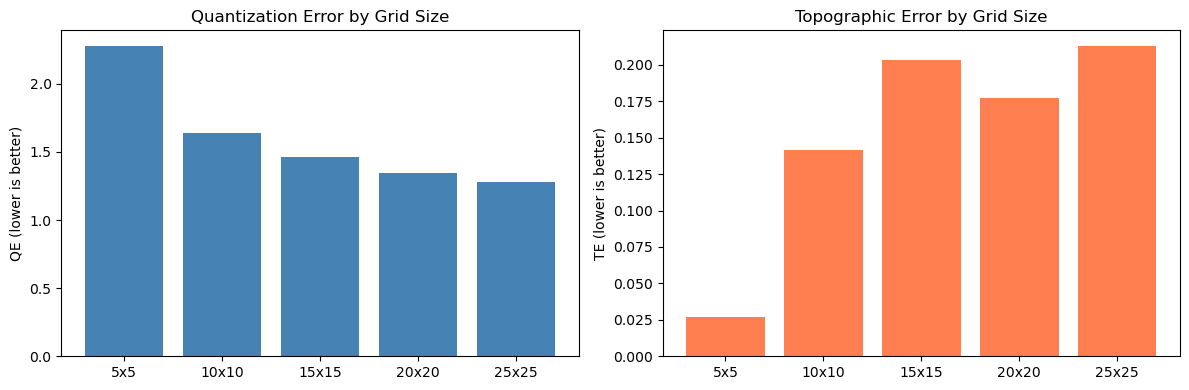

In [8]:
print(" Visualizing Results")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ticks = [f"{r[0]}x{r[1]}" for r in results]

ax1.bar(ticks, [r[2] for r in results], color='steelblue')
ax1.set_title('Quantization Error by Grid Size')
ax1.set_ylabel('QE (lower is better)')

ax2.bar(ticks, [r[3] for r in results], color='coral')
ax2.set_title('Topographic Error by Grid Size')
ax2.set_ylabel('TE (lower is better)')

plt.tight_layout()
plt.show()

In [9]:

print(" Training Final SOM")

print(f"\nTraining final SOM with optimal grid {optimal_grid[0]}x{optimal_grid[1]}")
som_final = MiniSom(optimal_grid[0], optimal_grid[1], n_features, 
                    sigma=1.5, learning_rate=0.5, random_seed=42)
som_final.random_weights_init(df_scaled.values)
som_final.train(df_scaled.values, 5000)

weights_final = som_final.get_weights()
sx_f, sy_f = weights_final.shape[:2]


qe_final_errors = []
for x in df_scaled.values:
    min_dist = min(np.linalg.norm(x - weights_final[i, j])
                   for i in range(sx_f) for j in range(sy_f))
    qe_final_errors.append(min_dist)
qe_final = np.mean(qe_final_errors)


te_final_errors = 0
for x in df_scaled.values:
    distances = sorted(
        [(np.linalg.norm(x - weights_final[i, j]), i, j)
         for i in range(sx_f) for j in range(sy_f)]
    )
    _, i1, j1 = distances[0]
    _, i2, j2 = distances[1]
    if abs(i1 - i2) > 1 or abs(j1 - j2) > 1:
        te_final_errors += 1
te_final = te_final_errors / len(df_scaled.values)


print("FINAL SOM PERFORMANCE:")
print(f"Quantization Error (QE): {qe_final:.6f}")
print(f"Topographic Error (TE): {te_final:.4f}")



 Training Final SOM

Training final SOM with optimal grid 20x20
FINAL SOM PERFORMANCE:
Quantization Error (QE): 1.196897
Topographic Error (TE): 0.1922


---
## 5. GMM with RBM


In [5]:


rbm = BernoulliRBM(n_components=15, learning_rate=0.01, n_iter=100, random_state=42)
X_rbm = rbm.fit_transform(df_scaled)

print(f'RBM transformed shape: {X_rbm.shape}')

RBM transformed shape: (5452, 15)


In [6]:
n_range = range(2, 8)
gmm_results = []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full',
                          n_init=10, max_iter=300, random_state=42)
    gmm.fit(X_rbm)
    labels = gmm.predict(X_rbm)
    weights = gmm.weights_
    min_weight = weights.min()
    sil = silhouette_score(X_rbm, labels) if len(np.unique(labels)) > 1 else -1
    gmm_results.append({
        'n': n, 'BIC': gmm.bic(X_rbm), 'AIC': gmm.aic(X_rbm),
        'LogLik': gmm.score(X_rbm), 'Silhouette': sil,
        'min_weight': round(min_weight, 4)  
    })

gmm_df = pd.DataFrame(gmm_results)
print(gmm_df.to_string(index=False))

valid_gmm = gmm_df[gmm_df['min_weight'] > 0.07]
if len(valid_gmm) > 0:
    best_gmm_n = valid_gmm.loc[valid_gmm['BIC'].idxmin(), 'n']
    print(f'\nBest balanced n by BIC: {best_gmm_n}')
else:
    best_gmm_n = gmm_df.loc[gmm_df['Silhouette'].idxmax(), 'n']
    print(f'\nFallback: best silhouette n={best_gmm_n}')

 n            BIC            AIC    LogLik  Silhouette  min_weight
 2 -818206.689429 -819996.302371 75.251128    0.937903      0.4967
 3 -842911.213245 -845598.934527 77.624077    0.994116      0.1774
 4 -862555.693120 -866141.522742 79.532972    0.992374      0.0007
 5 -914453.777324 -918937.715285 84.399827    0.988771      0.0007
 6 -889137.765363 -894519.811664 82.185419    0.994830      0.0007
 7 -901061.292567 -907341.447208 83.386230    0.995464      0.0007

Best balanced n by BIC: 3


GMM+RBM Final (n=3):
Silhouette: 0.994116

  Cluster 0:   967 ( 17.7%) █████
  Cluster 1: 2,744 ( 50.3%) ███████████████
  Cluster 2: 1,741 ( 31.9%) █████████


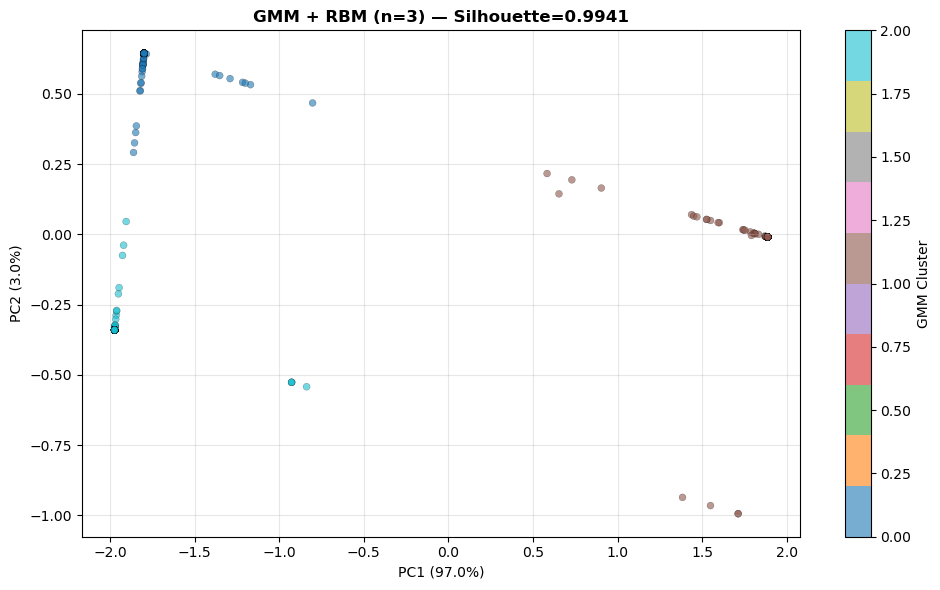

In [7]:
final_gmm = GaussianMixture(n_components=3, covariance_type='full',
                             n_init=10, max_iter=300, random_state=42)
final_gmm.fit(X_rbm)
gmm_labels = final_gmm.predict(X_rbm)
gmm_proba  = final_gmm.predict_proba(X_rbm)
gmm_sil    = silhouette_score(X_rbm, gmm_labels)

print(f'GMM+RBM Final (n={best_gmm_n}):')
print(f'Silhouette: {gmm_sil:.6f}')
print()
gmm_counts = pd.Series(gmm_labels).value_counts().sort_index()
for cl, cnt in gmm_counts.items():
    w = final_gmm.weights_[cl]
    bar = '█' * int(w * 30)
    print(f'  Cluster {cl}: {cnt:5,} ({w*100:5.1f}%) {bar}')

pca2 = PCA(n_components=2)
pca2_result = pca2.fit_transform(X_rbm)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pca2_result[:, 0], pca2_result[:, 1],
                      c=gmm_labels, cmap='tab10', alpha=0.6, s=25,
                      edgecolors='k', linewidth=0.2)
plt.colorbar(scatter, label='GMM Cluster')
plt.title(f'GMM + RBM (n={best_gmm_n}) — Silhouette={gmm_sil:.4f}', fontweight='bold')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('gmm_rbm_pca.png', dpi=150)
plt.show()

---
## 6. DBSCAN


In [10]:
print('Testing PCA components for DBSCAN:')
for n_comp in [5, 7, 10, 15]:
    pca_test = PCA(n_components=n_comp, random_state=42)
    X_test = pca_test.fit_transform(df_scaled)
    var = pca_test.explained_variance_ratio_.sum()
    print(f'  {n_comp} components: {var:.2%} variance explained')

N_PCA_DBSCAN = 7
pca_dbscan = PCA(n_components=N_PCA_DBSCAN, random_state=42)
X_pca_dbscan = pca_dbscan.fit_transform(df_scaled)

std_scaler = StandardScaler()
X_pca_dbscan = std_scaler.fit_transform(X_pca_dbscan)

var_explained = pca_dbscan.explained_variance_ratio_.sum()
print(f'\nUsing {N_PCA_DBSCAN} PCA components: {var_explained:.2%} variance')
print('Applied StandardScaler on PCA output')

Testing PCA components for DBSCAN:
  5 components: 98.86% variance explained
  7 components: 99.23% variance explained
  10 components: 99.60% variance explained
  15 components: 99.85% variance explained

Using 7 PCA components: 99.23% variance
Applied StandardScaler on PCA output


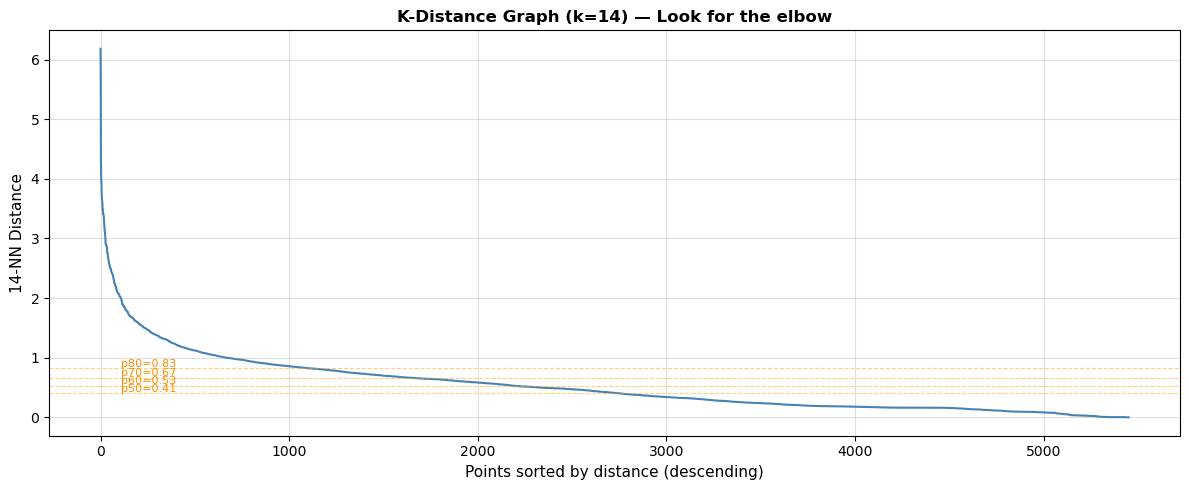


Eps candidates (p50–p75): [0.41  0.532 0.665 0.738]


In [11]:
k_neighbors = N_PCA_DBSCAN * 2
nn_model = NearestNeighbors(n_neighbors=5)
nn_model.fit(X_pca_dbscan)
distances, _ = nn_model.kneighbors(X_pca_dbscan)
kth_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(12, 5))
plt.plot(kth_distances, linewidth=1.5, color='steelblue')
for p in [50, 60, 70, 80]:
    val = np.percentile(kth_distances, p)
    plt.axhline(y=val, color='orange', linestyle='--', alpha=0.5, linewidth=0.8)
    plt.text(len(kth_distances)*0.02, val+0.02, f'p{p}={val:.2f}', fontsize=8, color='darkorange')
plt.xlabel('Points sorted by distance (descending)', fontsize=11)
plt.ylabel(f'{k_neighbors}-NN Distance', fontsize=11)
plt.title(f'K-Distance Graph (k={k_neighbors}) — Look for the elbow', fontsize=12, fontweight='bold')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150)
plt.show()

eps_candidates = np.unique(np.round(np.percentile(kth_distances, [50, 60, 70, 75]), 3))
print(f'\nEps candidates (p50–p75): {eps_candidates}')

In [12]:
min_samples_range = [10, 15, 20, 30, 50]
MIN_CLUSTER_SIZE  = 100  

dbscan_results = []

for eps in eps_candidates:
    for min_s in min_samples_range:
        db = DBSCAN(eps=eps, min_samples=min_s, n_jobs=-1)
        labels = db.fit_predict(X_pca_dbscan)

        unique_labels = set(labels)
        n_clusters_found = len(unique_labels) - (1 if -1 in unique_labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100

        if n_clusters_found > 0:
            cl_counts = pd.Series(labels[labels != -1]).value_counts()
            valid_clusters = (cl_counts >= MIN_CLUSTER_SIZE).sum()
        else:
            valid_clusters = 0

        if valid_clusters > 1 and noise_pct < 25:
            mask = labels != -1
            sil = silhouette_score(X_pca_dbscan[mask], labels[mask])
        else:
            sil = -1

        dbscan_results.append({
            'eps': eps, 'min_samples': min_s,
            'n_clusters_total': n_clusters_found,
            'n_clusters_valid': valid_clusters,
            'noise_pct': round(noise_pct, 1),
            'silhouette': round(sil, 4)
        })

dbscan_df = pd.DataFrame(dbscan_results)
print('DBSCAN Grid Search Results:')
print(dbscan_df.sort_values('silhouette', ascending=False).to_string(index=False))

DBSCAN Grid Search Results:
  eps  min_samples  n_clusters_total  n_clusters_valid  noise_pct  silhouette
0.410           10                36                 8       54.1          -1
0.410           15                21                 8       60.3          -1
0.410           20                21                 7       63.8          -1
0.410           30                11                 6       71.7          -1
0.410           50                 5                 4       80.0          -1
0.532           10                25                 3       44.1          -1
0.532           15                20                 5       51.4          -1
0.532           20                17                 5       56.4          -1
0.532           30                10                 5       64.3          -1
0.532           50                 6                 4       73.1          -1
0.665           10                21                 4       33.7          -1
0.665           15                13

In [13]:
valid_results = dbscan_df[dbscan_df['silhouette'] > 0]

if len(valid_results) > 0:
    best_dbscan = valid_results.sort_values('silhouette', ascending=False).iloc[0]
    best_eps   = best_dbscan['eps']
    best_min_s = int(best_dbscan['min_samples'])
    print(f'Best config → eps={best_eps}, min_samples={best_min_s}')
else:
    fallback = dbscan_df[dbscan_df['n_clusters_valid'] > 0].sort_values('noise_pct').iloc[0]
    best_eps   = fallback['eps']
    best_min_s = int(fallback['min_samples'])
    print(f'No ideal config — fallback: eps={best_eps}, min_samples={best_min_s}')

best_db = DBSCAN(eps=best_eps, min_samples=best_min_s, n_jobs=-1)
dbscan_labels = best_db.fit_predict(X_pca_dbscan)

unique_lbl = set(dbscan_labels)
n_clusters_final = len(unique_lbl) - (1 if -1 in unique_lbl else 0)
n_noise_final    = (dbscan_labels == -1).sum()

print(f'\nFinal DBSCAN Results:')
print(f'  Clusters found:  {n_clusters_final}')
print(f'  Noise points:    {n_noise_final} ({n_noise_final/len(dbscan_labels)*100:.1f}%)')

if n_clusters_final > 1:
    mask = dbscan_labels != -1
    dbscan_sil = silhouette_score(X_pca_dbscan[mask], dbscan_labels[mask])
    print(f'  Silhouette (excl. noise): {dbscan_sil:.6f}')
else:
    dbscan_sil = -1
    print('  Warning: Only 1 cluster — DBSCAN did not converge well on this data')
    print('  Consider: this dataset may be too continuous for density-based clustering')

print('\nCluster distribution:')
for lbl, cnt in sorted(pd.Series(dbscan_labels).value_counts().items()):
    tag = '(NOISE)' if lbl == -1 else ''
    bar = '█' * int(cnt / len(dbscan_labels) * 30)
    print(f'  Cluster {lbl:3d}: {cnt:6,} ({cnt/len(dbscan_labels)*100:.1f}%) {tag} {bar}')

No ideal config — fallback: eps=0.738, min_samples=10

Final DBSCAN Results:
  Clusters found:  14
  Noise points:    1544 (28.3%)
  Silhouette (excl. noise): 0.045657

Cluster distribution:
  Cluster  -1:  1,544 (28.3%) (NOISE) ████████
  Cluster   0:     13 (0.2%)  
  Cluster   1:    690 (12.7%)  ███
  Cluster   2:    145 (2.7%)  
  Cluster   3:    710 (13.0%)  ███
  Cluster   4:  2,137 (39.2%)  ███████████
  Cluster   5:     32 (0.6%)  
  Cluster   6:     14 (0.3%)  
  Cluster   7:     42 (0.8%)  
  Cluster   8:     24 (0.4%)  
  Cluster   9:     28 (0.5%)  
  Cluster  10:     32 (0.6%)  
  Cluster  11:     18 (0.3%)  
  Cluster  12:     15 (0.3%)  
  Cluster  13:      8 (0.1%)  


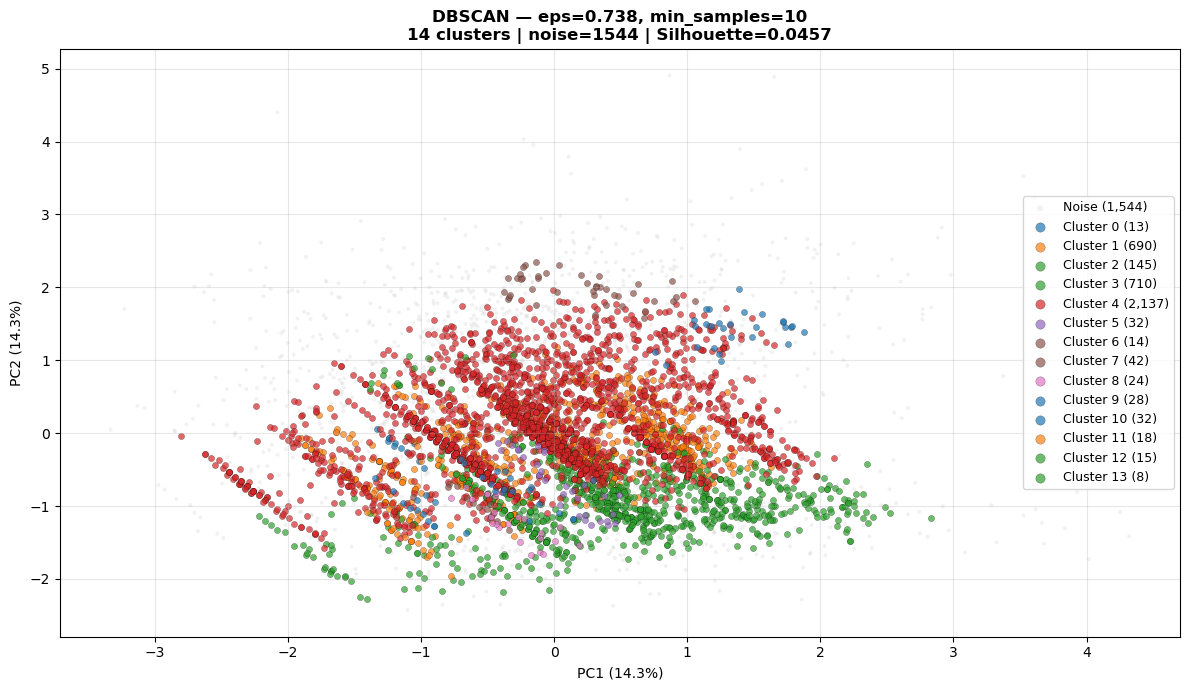

In [14]:
pca_vis = PCA(n_components=2)
X_vis_2d = pca_vis.fit_transform(X_pca_dbscan)

unique_labels = sorted(set(dbscan_labels))
n_real = max(len(unique_labels), 10)
colors = plt.cm.tab10(np.linspace(0, 1, n_real))

plt.figure(figsize=(12, 7))
for idx, k in enumerate(unique_labels):
    if k == -1:
        col, lbl, alpha, size = 'lightgray', 'Noise', 0.3, 8
    else:
        col, lbl, alpha, size = colors[idx % 10], f'Cluster {k}', 0.7, 20
    mask = dbscan_labels == k
    plt.scatter(X_vis_2d[mask, 0], X_vis_2d[mask, 1],
                c=[col], s=size, alpha=alpha,
                edgecolors='k' if k != -1 else 'none',
                linewidth=0.2, label=f'{lbl} ({mask.sum():,})')

plt.legend(loc='best', fontsize=9, markerscale=1.5)
sil_str = f'Silhouette={dbscan_sil:.4f}' if dbscan_sil > 0 else 'N/A'
plt.title(f'DBSCAN — eps={best_eps}, min_samples={best_min_s}\n'
          f'{n_clusters_final} clusters | noise={n_noise_final} | {sil_str}',
          fontweight='bold')
plt.xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.1%})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_pca.png', dpi=150)
plt.show()

---
## 7. SVM Classifier


In [15]:
bmu_coordinates = np.array([som_final.winner(x) for x in df_scaled.values])

som_weights = som_final.get_weights().reshape(-1, df_scaled.shape[1])

som_x, som_y = som_final.get_weights().shape[:2]

km = KMeans(n_clusters=2, random_state=42, n_init=20)
neuron_clusters = km.fit_predict(som_weights).reshape(som_x, som_y)

sample_clusters = [neuron_clusters[c[0], c[1]] for c in bmu_coordinates]


In [16]:
df_model['SOM_Cluster'] = sample_clusters
X_svm = df_model.drop(columns=['SOM_Cluster', 'DBSCAN_Cluster'], errors='ignore')
y_svm = df_model['SOM_Cluster']

print(f'SVM dataset: {X_svm.shape[0]:,} samples | {X_svm.shape[1]} features')

X_train, X_test, y_train, y_test = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
)

svm_scaler = RobustScaler()
X_train_sc = svm_scaler.fit_transform(X_train)
X_test_sc  = svm_scaler.transform(X_test)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

SVM dataset: 5,452 samples | 36 features
Train: 4,361 | Test: 1,091


In [17]:
svm_results = []
gammas = [0.001, 0.005, 0.01, 0.05, 0.1]
Cs     = [0.1, 0.5, 1, 5, 10, 50]

print(f'Running SVM grid search ({len(gammas)}×{len(Cs)}={len(gammas)*len(Cs)} combos)...')
for gamma in gammas:
    for C in Cs:
        model = SVC(kernel='rbf', gamma=gamma, C=C, random_state=42, class_weight='balanced')
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        acc = accuracy_score(y_test, y_pred)
        sil = silhouette_score(X_test_sc, y_pred) if len(np.unique(y_pred)) > 1 else -1
        svm_results.append({'gamma': gamma, 'C': C, 'accuracy': round(acc, 4), 'silhouette': round(sil, 4)})

df_svm = pd.DataFrame(svm_results)
print('\nTop 10 configs by silhouette:')
print(df_svm.sort_values('silhouette', ascending=False).head(10).to_string(index=False))

Running SVM grid search (5×6=30 combos)...

Top 10 configs by silhouette:
 gamma    C  accuracy  silhouette
 0.050  0.1    0.9835      0.7709
 0.010  0.1    0.9927      0.7667
 0.005  0.1    0.9954      0.7666
 0.001  0.1    0.9982      0.7591
 0.100  0.1    0.9734      0.7492
 0.001  5.0    1.0000      0.7471
 0.001 50.0    1.0000      0.7471
 0.001 10.0    1.0000      0.7471
 0.005  1.0    1.0000      0.7471
 0.005  0.5    1.0000      0.7471


In [18]:
best_row = df_svm.loc[df_svm['silhouette'].idxmax()]

best_model = SVC(
    kernel='rbf',
    gamma=best_row['gamma'],
    C=best_row['C'],
    class_weight='balanced',
    random_state=42
)

best_model.fit(X_train_sc, y_train)
y_pred_best = best_model.predict(X_test_sc)

print('=' * 50)
print('BEST SVM MODEL')
print('=' * 50)

print(f'Gamma={best_row["gamma"]}, C={best_row["C"]}')
print(f'Accuracy:   {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Silhouette: {silhouette_score(X_test_sc, y_pred_best):.4f}')

BEST SVM MODEL
Gamma=0.05, C=0.1
Accuracy:   0.9835
Silhouette: 0.7709


In [19]:
import pickle

def save_svm_model(model, scaler, X_test, y_test, y_pred, filename='svm_model'):
    """Save trained SVM model, scaler, and predictions"""

    with open(f'{filename}.pkl', 'wb') as file:
        pickle.dump(model, file)

    with open(f'{filename}_scaler.pkl', 'wb') as file:
        pickle.dump(scaler, file)

    results_df = X_test.copy()
    results_df['Actual'] = y_test
    results_df['Predicted'] = y_pred

    results_df.to_csv(f'{filename}_results.csv', index=False)

    print(f" Saved: {filename}.pkl")
    print(f" Saved: {filename}_scaler.pkl")
    print(f" Saved: {filename}_results.csv")

In [20]:
save_svm_model(
    best_model,
    svm_scaler,
    X_test,
    y_test,
    y_pred_best,
    'customer_svm'
)

 Saved: customer_svm.pkl
 Saved: customer_svm_scaler.pkl
 Saved: customer_svm_results.csv


---
## 8- KMeans

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

print("KMeans on PCA features:")
print("-" * 35)

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(df_scaled)

    score = silhouette_score(df_scaled, labels)
    scores.append(score)

    print(f"k={k} → silhouette={score:.4f}")

KMeans on PCA features:
-----------------------------------
k=2 → silhouette=0.7709
k=3 → silhouette=0.7271
k=4 → silhouette=0.7562
k=5 → silhouette=0.7631
k=6 → silhouette=0.7682
k=7 → silhouette=0.7702


In [24]:
best_k = range(2, 8)[scores.index(max(scores))]
print("Best k:", best_k)

Best k: 2


In [25]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
final_labels = kmeans.fit_predict(df_scaled)

df_model['Cluster'] = final_labels

counts = pd.Series(final_labels).value_counts().sort_index()

print("Final clusters:")
for cl, cnt in counts.items():
    bar = '█' * int(cnt / len(final_labels) * 30)
    print(f"Cluster {cl}: {cnt} ({cnt/len(final_labels)*100:.1f}%) {bar}")

print("-" * 40)
print("Final Silhouette:", silhouette_score(df_scaled, final_labels))

Final clusters:
Cluster 0: 5081 (93.2%) ███████████████████████████
Cluster 1: 371 (6.8%) ██
----------------------------------------
Final Silhouette: 0.7708883512863933


### Data

In [26]:
X_np = df_scaled.values.astype(np.float32)
X_tensor = torch.tensor(X_np).to(device)
input_dim = X_np.shape[1]


#  Autoencoder

In [27]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


#  Clustering Layer (DEC)

In [28]:
class ClusteringLayer(nn.Module):
    def __init__(self, n_clusters, latent_dim):
        super().__init__()
        self.cluster_centers = nn.Parameter(torch.empty(n_clusters, latent_dim))
        nn.init.xavier_uniform_(self.cluster_centers)

    def forward(self, z):
        z_exp = z.unsqueeze(1)
        c_exp = self.cluster_centers.unsqueeze(0)

        dist = torch.sum((z_exp - c_exp) ** 2, dim=2)
        q = 1.0 / (1.0 + dist)
        q = q / torch.sum(q, dim=1, keepdim=True)
        return q


def target_distribution(q):
    f = torch.sum(q, dim=0, keepdim=True)
    p = (q ** 2) / f
    return p / torch.sum(p, dim=1, keepdim=True)

#  DEC Model

In [29]:
class DEC(nn.Module):
    def __init__(self, encoder, clustering):
        super().__init__()
        self.encoder = encoder
        self.clustering = clustering

    def forward(self, x):
        z = self.encoder(x)
        q = self.clustering(z)
        return z, q


#  Pretrain Autoencoder

In [30]:
def pretrain_ae(latent_dim, epochs=30):
    ae = Autoencoder(input_dim, latent_dim).to(device)
    opt = optim.Adam(ae.parameters(), lr=1e-3)

    loader = DataLoader(TensorDataset(X_tensor), batch_size=256, shuffle=True)

    ae.train()
    for _ in range(epochs):
        for (xb,) in loader:
            x_hat, _ = ae(xb)
            loss = nn.functional.mse_loss(x_hat, xb)

            opt.zero_grad()
            loss.backward()
            opt.step()

    return ae

#  Train DEC

In [ ]:
def train_dec(ae, n_clusters, latent_dim, epochs=40):

    with torch.no_grad():
        _, Z = ae(X_tensor)
    Z_np = Z.cpu().numpy()

    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42)
    kmeans.fit(Z_np)

    clustering = ClusteringLayer(n_clusters, latent_dim).to(device)

    with torch.no_grad():
        clustering.cluster_centers.copy_(
            torch.tensor(kmeans.cluster_centers_, dtype=torch.float32, device=device)
        )

    dec = DEC(ae.encoder, clustering).to(device)
    opt = optim.Adam(dec.parameters(), lr=1e-3)

    loader = DataLoader(
        TensorDataset(X_tensor, torch.arange(len(X_tensor))),
        batch_size=256,
        shuffle=True
    )

    for _ in range(epochs):

        dec.eval()
        with torch.no_grad():
            Z, q_all = dec(X_tensor)
            p_all = target_distribution(q_all)

        dec.train()
        for xb, idx in loader:
            _, q_batch = dec(xb)

            q_batch = torch.clamp(q_batch, min=1e-6)
            q_batch = q_batch / q_batch.sum(dim=1, keepdim=True)
            p_batch = p_all[idx]

            loss = nn.functional.kl_div(
                torch.log(q_batch),
                p_batch,
                reduction='batchmean'
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

    dec.eval()
    with torch.no_grad():
        Z, q = dec(X_tensor)
        labels = torch.argmax(q, dim=1).cpu().numpy()
        Z_np = Z.cpu().numpy()

    if len(np.unique(labels)) > 1:
        sil = silhouette_score(Z_np, labels)
    else:
        sil = -1

    return labels, sil


#  Run DEC


In [32]:
latent_dim = 5
cluster_options = [2, 3, 4, 5, 6]

results = []

ae = pretrain_ae(latent_dim)

for k in cluster_options:
    labels, sil = train_dec(ae, k, latent_dim)
    print(f"k={k} → silhouette={sil:.4f}")
    results.append((k, sil))

best_k, best_score = max(results, key=lambda x: x[1])

print("\nBEST CONFIG:")
print("latent_dim:", latent_dim)
print("clusters:", best_k)
print("silhouette:", best_score)

k=2 → silhouette=0.9827
k=3 → silhouette=0.9758
k=4 → silhouette=0.9724
k=5 → silhouette=0.9804
k=6 → silhouette=0.9821

BEST CONFIG:
latent_dim: 5
clusters: 2
silhouette: 0.9826705


In [ ]:
X_dec = df_model.drop(columns=[
    "SOM_Cluster",
    "DBSCAN_Cluster",
    "Cluster",
    "DEC_Cluster"
], errors="ignore")

scaler_dec = MinMaxScaler()

X_scaled_dec = scaler_dec.fit_transform(X_dec)

ae = pretrain_ae(5)

labels, sil = train_dec(ae, best_k, 5)

df_model["DEC_Cluster"] = labels



In [40]:
print("\nFinal DEC:")
print("Silhouette:", sil)


Final DEC:
Silhouette: 0.98156327


In [ ]:
import pickle
import torch
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler

print("=" * 60)
print("   Saving all clustering models...")
print("=" * 60)


with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ [1/10] scaler.pkl")


with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)
print("✅ [4/10] kmeans_model.pkl")


with open("gmm_model.pkl", "wb") as f:
    pickle.dump(final_gmm, f)
print("✅ [5/10] gmm_model.pkl")

mm_scaler_gmm = MinMaxScaler()

X_mm_gmm = mm_scaler_gmm.fit_transform(
    df_model.drop(
        columns=["SOM_Cluster", "DEC_Cluster", "DBSCAN_Cluster", "Cluster"],
        errors="ignore"
    )
)

from sklearn.neural_network import BernoulliRBM

rbm_save = BernoulliRBM(
    n_components=15,
    learning_rate=0.01,
    n_iter=100,
    random_state=42
)

rbm_save.fit(X_mm_gmm)

with open("rbm_model.pkl", "wb") as f:
    pickle.dump(rbm_save, f)

with open("mm_scaler_gmm.pkl", "wb") as f:
    pickle.dump(mm_scaler_gmm, f)

print("✅ [6/10] rbm_model.pkl + mm_scaler_gmm.pkl")

dbscan_meta = {
    "eps": best_eps,
    "min_samples": best_min_s,
    "labels": dbscan_labels.tolist(),
    "silhouette": round(dbscan_sil, 6),
    "n_clusters": n_clusters_final,
    "noise_pct": round((dbscan_labels == -1).sum() / len(dbscan_labels) * 100, 2),
}

with open("dbscan_meta.pkl", "wb") as f:
    pickle.dump(dbscan_meta, f)

core_mask_db = dbscan_labels != -1

X_db_core = df_scaled.values[core_mask_db]
y_db_core = dbscan_labels[core_mask_db]

dbscan_predictor = SVC(
    kernel="rbf",
    random_state=42,
    class_weight="balanced"
)

dbscan_predictor.fit(X_db_core, y_db_core)

with open("dbscan_predictor.pkl", "wb") as f:
    pickle.dump(dbscan_predictor, f)

print("✅ [7/10] dbscan_meta.pkl + dbscan_predictor.pkl")


mm_scaler_dec = MinMaxScaler()

X_mm_dec = mm_scaler_dec.fit_transform(
    df_model.drop(
        columns=["SOM_Cluster", "DEC_Cluster", "DBSCAN_Cluster", "Cluster"],
        errors="ignore"
    )
)

with open("mm_scaler_dec.pkl", "wb") as f:
    pickle.dump(mm_scaler_dec, f)

dec_checkpoint = {
    "autoencoder_state_dict": ae.state_dict(),

    "n_clusters": best_k,

    "input_dim": X_mm_dec.shape[1],

    "latent_dim": 5,

    "feature_names": list(
        df_model.drop(
            columns=["SOM_Cluster", "DEC_Cluster", "DBSCAN_Cluster", "Cluster"],
            errors="ignore"
        ).columns
    )
}

torch.save(dec_checkpoint, "real_dec_model.pt")

print("✅ [8/10] real_dec_model.pt")


dec_predictor = SVC(
    kernel="rbf",
    random_state=42
)

dec_predictor.fit(
    X_mm_dec,
    df_model["DEC_Cluster"]
)

with open("dec_predictor.pkl", "wb") as f:
    pickle.dump(dec_predictor, f)

print("✅ [9/10] dec_predictor.pkl")

dec_meta = {
    "n_clusters": 4,
    "model_type": "Deep Embedded Clustering",
    "predictor_type": "SVC",
    "scaler": "MinMaxScaler"
}

with open("dec_meta.pkl", "wb") as f:
    pickle.dump(dec_meta, f)

print("✅ [10/10] dec_meta.pkl")

print()
print("=" * 60)
print("   All models saved successfully!")
print("=" * 60)

   Saving all clustering models...
✅ [1/10] scaler.pkl
✅ [2/10] som_model.pkl
✅ [3/10] kmeans_som_model.pkl
✅ [4/10] kmeans_model.pkl
✅ [5/10] gmm_model.pkl
✅ [6/10] rbm_model.pkl + mm_scaler_gmm.pkl
✅ [7/10] dbscan_meta.pkl + dbscan_predictor.pkl
✅ [8/10] real_dec_model.pt
✅ [9/10] dec_predictor.pkl
✅ [10/10] dec_meta.pkl

   All models saved successfully!


In [45]:
low_risk = df_model[df_model["DEC_Cluster"] == 0].head(1)
print(low_risk[['age', 'Other', 'Savings', 'Diamond Bank', 'EcoBank', 'FCMB',
    'Fidelity Bank', 'First Bank', 'GT Bank', 'Heritage Bank',
    'Keystone Bank', 'Skye Bank', 'Stanbic IBTC', 'Standard Chartered',
    'Sterling Bank', 'UBA', 'Union Bank', 'Unity Bank', 'Wema Bank',
    'Zenith Bank', 'Not known', 'Permanent', 'Retired', 'Self-Employed',
    'Student', 'Unemployed', 'loanamount', 'totaldue', 'termdays',
    'totalamountreturn', 'interestrate', 'loannumberprevious',
    'loanamountprevious', 'totaldueprevious', 'termdaysprevious',
    'datediffsecondsprevious']].to_dict('records'))

[{'age': 48, 'Other': 0, 'Savings': 1, 'Diamond Bank': 0, 'EcoBank': 0, 'FCMB': 0, 'Fidelity Bank': 0, 'First Bank': 0, 'GT Bank': 1, 'Heritage Bank': 0, 'Keystone Bank': 0, 'Skye Bank': 0, 'Stanbic IBTC': 0, 'Standard Chartered': 0, 'Sterling Bank': 0, 'UBA': 0, 'Union Bank': 0, 'Unity Bank': 0, 'Wema Bank': 0, 'Zenith Bank': 0, 'Not known': 1, 'Permanent': 0, 'Retired': 0, 'Self-Employed': 0, 'Student': 0, 'Unemployed': 0, 'loanamount': 100000000, 'totaldue': 130000000.0, 'termdays': 30, 'totalamountreturn': 30000000.0, 'interestrate': 23.07692307692308, 'loannumberprevious': 1.0, 'loanamountprevious': 100000000.0, 'totaldueprevious': 115000000.0, 'termdaysprevious': 15.0, 'datediffsecondsprevious': 3667.0}]


In [46]:
high_risk = df_model[df_model["DEC_Cluster"] == 1].head(1)
print(high_risk[['age', 'Other', 'Savings', 'Diamond Bank', 'EcoBank', 'FCMB',
    'Fidelity Bank', 'First Bank', 'GT Bank', 'Heritage Bank',
    'Keystone Bank', 'Skye Bank', 'Stanbic IBTC', 'Standard Chartered',
    'Sterling Bank', 'UBA', 'Union Bank', 'Unity Bank', 'Wema Bank',
    'Zenith Bank', 'Not known', 'Permanent', 'Retired', 'Self-Employed',
    'Student', 'Unemployed', 'loanamount', 'totaldue', 'termdays',
    'totalamountreturn', 'interestrate', 'loannumberprevious',
    'loanamountprevious', 'totaldueprevious', 'termdaysprevious',
    'datediffsecondsprevious']].to_dict('records'))

[{'age': 34, 'Other': 0, 'Savings': 1, 'Diamond Bank': 0, 'EcoBank': 0, 'FCMB': 0, 'Fidelity Bank': 0, 'First Bank': 0, 'GT Bank': 0, 'Heritage Bank': 0, 'Keystone Bank': 0, 'Skye Bank': 0, 'Stanbic IBTC': 0, 'Standard Chartered': 0, 'Sterling Bank': 0, 'UBA': 0, 'Union Bank': 0, 'Unity Bank': 0, 'Wema Bank': 0, 'Zenith Bank': 1, 'Not known': 0, 'Permanent': 1, 'Retired': 0, 'Self-Employed': 0, 'Student': 0, 'Unemployed': 0, 'loanamount': 300000000, 'totaldue': 390000000.0, 'termdays': 60, 'totalamountreturn': 90000000.0, 'interestrate': 23.07692307692308, 'loannumberprevious': 3.5, 'loanamountprevious': 210000000.0, 'totaldueprevious': 252833333.3333333, 'termdaysprevious': 37.5, 'datediffsecondsprevious': 3609.8333333333335}]
